In [1]:
import sys
!{sys.executable} -m pip install rdkit-pypi


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: E:\Final_Year_Project\gnn_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install "numpy<2"


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: E:\Final_Year_Project\gnn_env\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
print(np.__version__)

1.26.4


In [4]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

print("RDKit is working")


RDKit is working


In [5]:
df = pd.read_csv("../data/raw/chembl/chembl_ic50_5000.csv")
print(df.shape)
df.head()

(4780, 4)


,canonical_smiles,molecule_chembl_id,standard_value,value
0,c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1,CHEMBL113081,100000.0,100.0
1,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,CHEMBL324340,2500.0,2.5
2,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,CHEMBL324340,50000.0,50.0
3,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...,CHEMBL109600,9000.0,9.0
4,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...,CHEMBL357278,4000.0,4.0


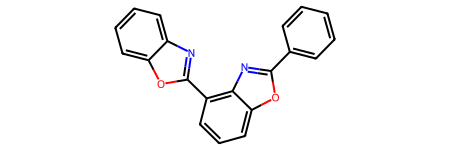

In [6]:
#SMILES parsing algorithm

smiles = df.loc[0, "canonical_smiles"]
mol = Chem.MolFromSmiles(smiles)

mol

In [7]:
#Graph construction algorithm

def mol_to_graph(mol):
    nodes = []
    edges = []

    for atom in mol.GetAtoms():
        nodes.append(atom.GetAtomicNum())

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edges.append((i, j))
        edges.append((j, i))

    return nodes, edges


In [8]:
nodes, edges = mol_to_graph(mol)
print("Nodes:", len(nodes))
print("Edges:", len(edges))

Nodes: 24
Edges: 56


In [9]:
graphs = []

for smi in df["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    nodes, edges = mol_to_graph(mol)
    graphs.append({
        "nodes": nodes,
        "edges": edges
    })

print("Graphs created:", len(graphs))

Graphs created: 4780


In [10]:
import pickle

with open("../data/processed/chembl_molecular_graphs.pkl", "wb") as f:
    pickle.dump(graphs, f)

print("Molecular graphs saved to data/processed/chembl_molecular_graphs.pkl")


Molecular graphs saved to data/processed/chembl_molecular_graphs.pkl


In [11]:
example_graph = graphs[0]  # first molecule
nodes = example_graph["nodes"]
edges = example_graph["edges"]

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(range(len(nodes)))
G.add_edges_from(edges)

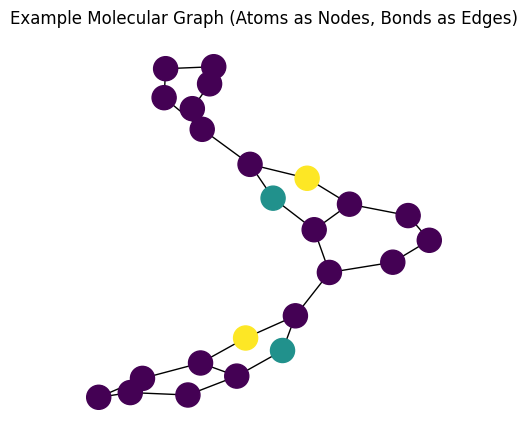

In [14]:
plt.figure(figsize=(4, 4))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_size=300,
    node_color=nodes,
    cmap="viridis",
    with_labels=False
)

plt.title("Example Molecular Graph (Atoms as Nodes, Bonds as Edges)")
plt.show()

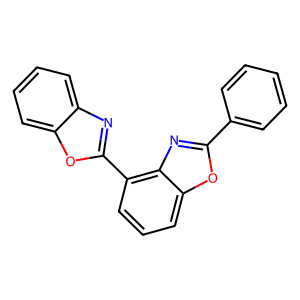

In [15]:
from rdkit.Chem import Draw

smiles = df.loc[0, "canonical_smiles"]
mol = Chem.MolFromSmiles(smiles)

Draw.MolToImage(mol)